Обработка объекта для расстояния: 37 мм
d=  37.0 shift= 702.0836 scale= 0.350740 pixel808=  301.98 I808=60.070588 R2=0.99448
Обработка объекта для расстояния: 54 мм
d=  54.0 shift= 714.9347 scale= 0.307458 pixel808=  302.69 I808=58.177027 R2=0.98289
Обработка объекта для расстояния: 58 мм
d=  58.0 shift= 714.6560 scale= 0.308472 pixel808=  302.60 I808=59.128000 R2=0.98193
Обработка объекта для расстояния: 61 мм
d=  61.0 shift= 713.8877 scale= 0.310488 pixel808=  303.11 I808=54.588136 R2=0.98721
Обработка объекта для расстояния: 65 мм
d=  65.0 shift= 714.8694 scale= 0.307200 pixel808=  303.16 I808=58.240580 R2=0.98223
Обработка объекта для расстояния: 77 мм
d=  77.0 shift= 713.5498 scale= 0.312474 pixel808=  302.27 I808=62.143636 R2=0.99155
Обработка объекта для расстояния: 91 мм
d=  91.0 shift= 716.3967 scale= 0.303524 pixel808=  301.80 I808=72.277143 R2=0.98795
Обработка объекта для расстояния: 96 мм
d=  96.0 shift= 717.8767 scale= 0.298624 pixel808=  301.80 I808=70.393421 R2=0.98698


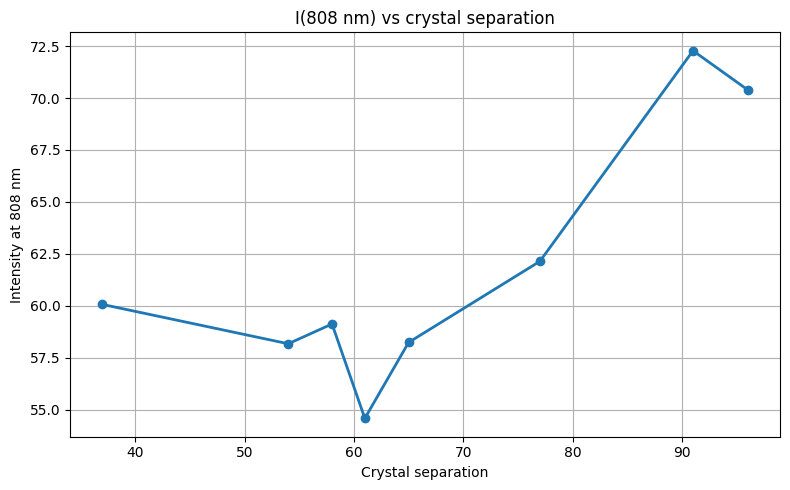


Анализ всей группы объектов успешно завершен.
Итоговые результаты сохранены в папку: analysis_output


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score


class CrystalExperiment:
    """
    Класс отдельного эксперимента (для конкретного расстояния между кристаллами).
    Хранит внутри себя настройки, сырые данные и результаты как с фильтром, так и без.
    """
    C_LIGHT = 299_792_458  # Скорость света (м/с)

    def __init__(self, filter_filename, config=None):
        self.filter_filename = filter_filename
        self.base_name = filter_filename.split("_")[0]
        self.distance = float(self.base_name)
        self.nofilter_filename = f"{self.base_name}_NOFILTER.png"

        # Дефолтная конфигурация эксперимента
        if config is None:
            config = {
                "left": 250, "right": 370,
                "top": 140, "bottom": 275,
                "target_wavelength": 808.0,
                "output_dir": "analysis_output"
            }
        self.config = config

        # Пути для сохранения графиков конкретно этого эксперимента
        self.filter_dir = os.path.join(config["output_dir"], "filter_fits")
        self.nofilter_dir = os.path.join(config["output_dir"], "nofilter_spectra")

        # Данные с фильтром (калибровка)
        self.fit_result = None

        # Данные без фильтра (анализ спектра)
        self.img_nf = None
        self.crop_nf = None
        self.spectrum_nf = None

        # Финальные рассчитанные физические параметры
        self.intensity = None
        self.pixel808 = None
        self.log_line = ""

    # ============================================================
    # МАТЕМАТИЧЕСКИЕ МОДЕЛИ (МЕТОДЫ КЛАССА)
    # ============================================================

    @staticmethod
    def _gaussian(w, w0, sig):
        return np.exp(-0.5 * ((w - w0) / sig) ** 2)

    @staticmethod
    def _convert_w_to_l(func, w_range, *params):
        l_range = 2 * np.pi * CrystalExperiment.C_LIGHT / w_range * 1e-3
        y_w = func(w_range, *params)
        y_l = y_w / l_range**2
        y_l /= np.max(y_l)
        return y_l

    @staticmethod
    def _gfit(pix, alpha, beta, shift, scale):
        wavelength = shift + scale * pix
        c_factor = 2 * np.pi * CrystalExperiment.C_LIGHT * 1e-3
        ang_freq = c_factor / wavelength

        l0 = 810
        l_fwhm = 10
        w0 = c_factor / l0

        w_fwhm = c_factor * l_fwhm / (l0**2 - (l_fwhm / 2)**2)
        sig_w = w_fwhm / (2 * np.sqrt(2 * np.log(2)))

        y_l = CrystalExperiment._convert_w_to_l(
            CrystalExperiment._gaussian, ang_freq, w0, sig_w
        )
        y_l /= np.max(y_l)

        return beta + alpha * y_l

    # ============================================================
    # ВСПОМОГАТЕЛЬНЫЕ МЕТОДЫ ОБРАБОТКИ ИЗОБРАЖЕНИЙ
    # ============================================================

    def _load_image(self, filename):
        img = Image.open(f"processed/{filename}").convert("L")
        img = np.array(img, dtype=float)
        img /= np.max(img)
        return img

    def _get_crop(self, img):
        return img[self.config["top"]:self.config["bottom"], self.config["left"]:self.config["right"]]

    def _get_1d_spectrum(self, img):
        crop = self._get_crop(img)
        return np.trapezoid(crop, axis=0)

    # ============================================================
    # ОСНОВНАЯ ЛОГИКА ЭКСПЕРИМЕНТА
    # ============================================================

    def run_calibration(self):
        """Шаг 1: Загрузка данных С ФИЛЬТРОМ и проведение калибровки."""
        img = self._load_image(self.filter_filename)
        crop = self._get_crop(img)

        x_pix = np.arange(self.config["left"], self.config["right"])
        y_exp = np.trapezoid(crop, axis=0)
        y_exp /= np.max(y_exp)

        p0 = [1.0, 0.1, 696.5, 0.37]

        popt, _ = curve_fit(
            self._gfit, x_pix, y_exp, p0=p0, maxfev=10000
        )

        alpha, beta, shift, scale = popt
        y_fit = self._gfit(x_pix, *popt)
        r2 = r2_score(y_exp, y_fit)

        self.fit_result = {
            "image": img, "crop": crop, "x_pix": x_pix,
            "y_exp": y_exp, "y_fit": y_fit,
            "alpha": alpha, "beta": beta,
            "shift": shift, "scale": scale, "r2": r2,
        }

    def process_nofilter_data(self):
        """Шаг 2: Обработка данных БЕЗ ФИЛЬТРА на основе полученной калибровки."""
        if self.fit_result is None:
            raise ValueError(f"Невозможно обработать {self.nofilter_filename} без предварительной калибровки!")

        shift = self.fit_result["shift"]
        scale = self.fit_result["scale"]

        self.img_nf = self._load_image(self.nofilter_filename)
        self.crop_nf = self._get_crop(self.img_nf)
        self.spectrum_nf = self._get_1d_spectrum(self.img_nf)

        # Поиск пикселя по длине волны
        pixel = (self.config["target_wavelength"] - shift) / scale
        pixel_global = int(round(pixel))
        pixel_local = pixel_global - self.config["left"]

        # Усреднение по окну
        averaging_window = 2
        start = max(0, pixel_local - averaging_window)
        stop = min(len(self.spectrum_nf), pixel_local + averaging_window + 1)

        self.intensity = np.mean(self.spectrum_nf[start:stop])
        self.pixel808 = pixel

        # Формирование строки для логов
        self.log_line = (
            f"d={self.distance:6.1f} "
            f"shift={shift:9.4f} "
            f"scale={scale:9.6f} "
            f"pixel808={self.pixel808:8.2f} "
            f"I808={self.intensity:.6f} "
            f"R2={self.fit_result['r2']:.5f}"
        )

    # ============================================================
    # ОТРИСОВКА И СОХРАНЕНИЕ ГРАФИКОВ
    # ============================================================

    def save_plots(self):
        """Сохранение индивидуальных графиков для данного эксперимента."""
        os.makedirs(self.filter_dir, exist_ok=True)
        os.makedirs(self.nofilter_dir, exist_ok=True)
        self._save_filter_plot()
        self._save_nofilter_plot()

    def _save_filter_plot(self):
        res = self.fit_result
        info = (
            f"File:\n{self.filter_filename}\n\n"
            f"alpha = {res['alpha']:.4f}\n"
            f"beta  = {res['beta']:.4f}\n\n"
            f"shift = {res['shift']:.4f} nm\n"
            f"scale = {res['scale']:.6f} nm/pixel\n\n"
            f"R² = {res['r2']:.5f}"
        )

        fig, ax = plt.subplots(2, 2, figsize=(10, 7))
        im0 = ax[0, 0].imshow(res["image"], aspect="auto")
        ax[0, 0].vlines([self.config["left"], self.config["right"]], 0, res["image"].shape[0])
        ax[0, 0].hlines([self.config["top"], self.config["bottom"]], 0, res["image"].shape[1])
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].imshow(
            res["crop"],
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto",
        )
        fig.colorbar(im1, ax=ax[0, 1])

        ax[1, 0].plot(res["x_pix"], res["y_exp"], ".", label="Experiment")
        ax[1, 0].plot(res["x_pix"], res["y_fit"], lw=2, label="Fit")
        ax[1, 0].grid()
        ax[1, 0].legend()

        ax[1, 1].axis("off")
        ax[1, 1].text(0.05, 0.95, info, va="top", family="monospace")

        plt.tight_layout()
        plt.savefig(os.path.join(self.filter_dir, self.filter_filename.replace(".png", "_fit.png")), dpi=300)
        plt.close()

    def _save_nofilter_plot(self):
        fig, ax = plt.subplots(2, 2, figsize=(10, 7))

        im0 = ax[0, 0].imshow(self.img_nf, aspect="auto")
        ax[0, 0].vlines([self.config["left"], self.config["right"]], 0, self.img_nf.shape[0])
        ax[0, 0].hlines([self.config["top"], self.config["bottom"]], 0, self.img_nf.shape[1])
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].imshow(
            self.crop_nf,
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto",
        )
        fig.colorbar(im1, ax=ax[0, 1])

        x_pix = np.arange(self.config["left"], self.config["right"])
        ax[1, 0].plot(x_pix, self.spectrum_nf)
        ax[1, 0].axvline(self.pixel808, color="red", linestyle="--", label="808 nm")
        ax[1, 0].legend()
        ax[1, 0].grid()

        ax[1, 1].axis("off")
        ax[1, 1].text(
            0.05, 0.95,
            f"\npixel(808 nm) = {self.pixel808:.2f}\n\nI(808 nm) = {self.intensity:.5f}\n",
            va="top", family="monospace"
        )

        plt.tight_layout()
        plt.savefig(os.path.join(self.nofilter_dir, self.nofilter_filename.replace(".png", "_spectrum.png")), dpi=300)
        plt.close()


class SpectroscopyBatchAnalyzer:
    """
    Класс-менеджер для агрегации нескольких объектов-экспериментов,
    их упорядочивания и построения финального аналитического отчета.
    """
    def __init__(self, output_dir="analysis_output"):
        self.output_dir = output_dir
        self.experiments = []

    def add_experiment(self, exp: CrystalExperiment):
        """Регистрирует объект эксперимента в общем пуле."""
        self.experiments.append(exp)

    def process_all(self):
        """Запускает последовательный конвейер обработки для каждого объекта."""
        os.makedirs(self.output_dir, exist_ok=True)

        for exp in self.experiments:
            print("=" * 60)
            print(f"Обработка объекта для расстояния: {exp.base_name} мм")
            
            exp.run_calibration()          # Шаг 1: Калибровка внутри объекта
            exp.process_nofilter_data()    # Шаг 2: Обработка "без фильтра" внутри объекта
            exp.save_plots()               # Шаг 3: Сохранение локальных графиков объекта
            
            print(exp.log_line)

        # Вызов финальной сборки данных по всем обработанным объектам
        self._generate_summary_report()

    def _generate_summary_report(self):
        # Вместо старого np.argsort сортируем сами объекты прямо в списке по их свойству distance
        self.experiments.sort(key=lambda x: x.distance)

        # Собираем массивы интенсивностей из уже готовых объектов
        distances = np.array([exp.distance for exp in self.experiments])
        intensities = np.array([exp.intensity for exp in self.experiments])

        # Построение финального сводного графика
        plt.figure(figsize=(8, 5))
        plt.plot(distances, intensities, "o-", linewidth=2)
        plt.xlabel("Crystal separation")
        plt.ylabel("Intensity at 808 nm")
        plt.title("I(808 nm) vs crystal separation")
        plt.grid()
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "intensity_vs_distance.png"), dpi=300)
        plt.show()

        # Запись общего лог-файла на основе данных из объектов
        log_path = os.path.join(self.output_dir, "analysis_log.txt")
        with open(log_path, "w", encoding="utf-8") as f:
            f.write("Intensity at 808 nm\n")
            f.write("=" * 50 + "\n\n")
            for exp in self.experiments:
                f.write(exp.log_line + "\n")

        print("\nАнализ всей группы объектов успешно завершен.")
        print(f"Итоговые результаты сохранены в папку: {self.output_dir}")


# ============================================================
# РАБОТА С ОБЪЕКТАМИ (MAIN PIPELINE)
# ============================================================
if __name__ == "__main__":
    # Исходный список файлов калибровочных фильтров
    filter_names = [
        "37_FILTER.png",
        "54_FILTER.png",
        "58_FILTER.png",
        "61_FILTER.png",
        "65_FILTER.png",
        "77_FILTER.png",
        "91_FILTER.png",
        "96_FILTER.png",
    ]

    # Единый конфигурационный словарь параметров (параметры кропа, таргет)
    config_params = {
        "left": 250, "right": 370,
        "top": 140, "bottom": 275,
        "target_wavelength": 808.0,
        "output_dir": "analysis_output"
    }

    # Инициализируем управляющий менеджер пакета
    batch_manager = SpectroscopyBatchAnalyzer(output_dir=config_params["output_dir"])

    # Создаем по объекту класса CrystalExperiment на каждый эксперимент и передаем их менеджеру
    for filename in filter_names:
        experiment_object = CrystalExperiment(filter_filename=filename, config=config_params)
        batch_manager.add_experiment(experiment_object)

    # Запускаем пакетную обработку
    batch_manager.process_all()

------------------------------------------------------------
d=  37.0 | Vis_Max=0.57199 | Intensity=0.8381 | Pairs=2
------------------------------------------------------------
d=  54.0 | Vis_Max=0.43323 | Intensity=0.8992 | Pairs=6
------------------------------------------------------------
d=  58.0 | Vis_Max=0.41869 | Intensity=0.9162 | Pairs=6
------------------------------------------------------------
d=  61.0 | Vis_Max=0.39703 | Intensity=0.8857 | Pairs=4
------------------------------------------------------------
d=  65.0 | Vis_Max=0.41273 | Intensity=0.9192 | Pairs=4
------------------------------------------------------------
d=  77.0 | Vis_Max=0.31426 | Intensity=0.8006 | Pairs=6
------------------------------------------------------------
d=  91.0 | Vis_Max=0.30515 | Intensity=0.8867 | Pairs=8
------------------------------------------------------------
d=  96.0 | Vis_Max=0.28731 | Intensity=0.8509 | Pairs=10
------------------------------------------------------------
d=

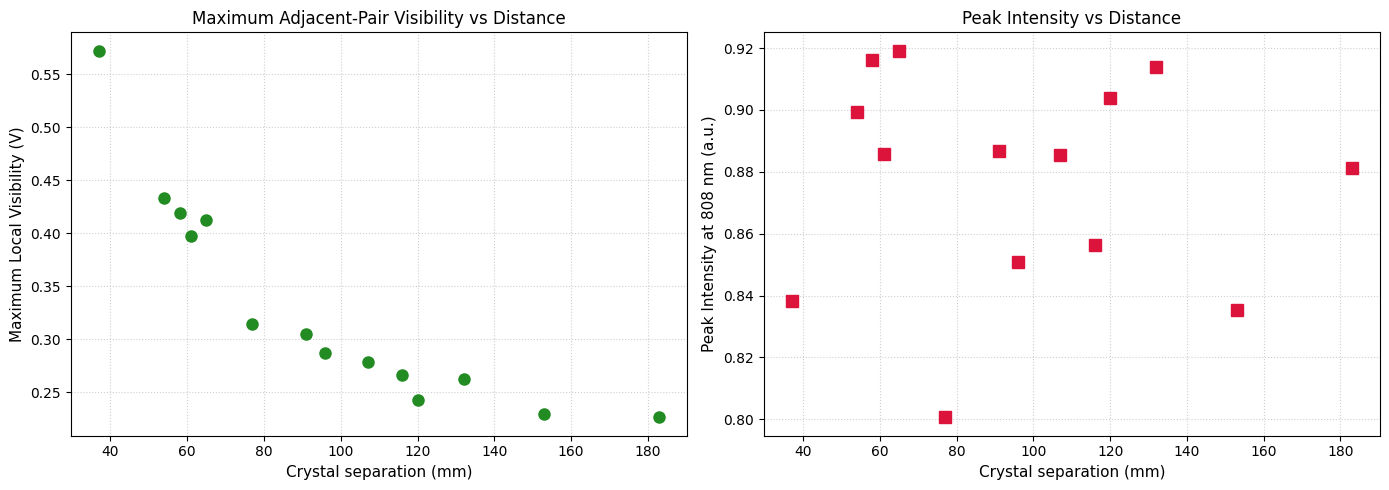


[Успех] Комплексный отчет сохранен в 'analysis_output/summary_analysis_report.png'.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from sklearn.metrics import r2_score


class CrystalExperiment:
    """
    Класс отдельного эксперимента.
    Проводит калибровку по фильтру с выводом полной плашки коэффициентов,
    находит максимумы и минимумы на 808 нм, считает интенсивность и макс. видность.
    """
    C_LIGHT = 299_792_458

    def __init__(self, filter_filename, config=None):
        self.filter_filename = filter_filename
        self.base_name = filter_filename.split("_")[0]
        self.distance = float(self.base_name)
        self.nofilter_filename = f"{self.base_name}_NOFILTER.png"

        if config is None:
            config = {
                "left": 250, "right": 370,
                "top": 140, "bottom": 275,
                "target_wavelength": 808.0,
                "output_dir": "analysis_output",
                "stripe_width": 3,
                "savgol_window": 13,
                "savgol_poly": 2,
                "peak_prominence": 0.008,
                "valley_prominence": 0.008,
                "peak_distance": 6,
                "peak_height_min": 0.12
            }
        self.config = config

        self.filter_dir = os.path.join(config["output_dir"], "filter_fits")
        self.nofilter_dir = os.path.join(config["output_dir"], "nofilter_spectra")

        self.fit_result = None
        self.img_nf = None
        self.crop_nf = None
        self.spectrum_nf = None
        
        self.slice_808 = None
        self.smoothed_slice = None
        
        self.peaks_idx = []
        self.valleys_idx = []
        self.paired_extrema = []  
        self.local_visibilities = []

        self.pixel808 = None
        self.visibility = 0.0
        self.intensity = 0.0  
        self.log_line = ""

    @staticmethod
    def _gaussian(w, w0, sig):
        return np.exp(-0.5 * ((w - w0) / sig) ** 2)

    @staticmethod
    def _convert_w_to_l(func, w_range, *params):
        l_range = 2 * np.pi * CrystalExperiment.C_LIGHT / w_range * 1e-3
        y_w = func(w_range, *params)
        y_l = y_w / l_range**2
        y_l /= np.max(y_l)
        return y_l

    @staticmethod
    def _gfit(pix, alpha, beta, shift, scale):
        wavelength = shift + scale * pix
        c_factor = 2 * np.pi * CrystalExperiment.C_LIGHT * 1e-3
        ang_freq = c_factor / wavelength
        l0 = 810
        l_fwhm = 10
        w0 = c_factor / l0
        w_fwhm = c_factor * l_fwhm / (l0**2 - (l_fwhm / 2)**2)
        sig_w = w_fwhm / (2 * np.sqrt(2 * np.log(2)))
        y_l = CrystalExperiment._convert_w_to_l(CrystalExperiment._gaussian, ang_freq, w0, sig_w)
        y_l /= np.max(y_l)
        return beta + alpha * y_l

    def _load_image(self, filename):
        img = Image.open(f"processed/{filename}").convert("L")
        img = np.array(img, dtype=float)
        img /= np.max(img)
        return img

    def _get_crop(self, img):
        return img[self.config["top"]:self.config["bottom"], self.config["left"]:self.config["right"]]

    def run_calibration(self):
        img = self._load_image(self.filter_filename)
        crop = self._get_crop(img)
        x_pix = np.arange(self.config["left"], self.config["right"])
        y_exp = np.trapezoid(crop, axis=0)
        y_exp /= np.max(y_exp)

        p0 = [1.0, 0.1, 696.5, 0.37]
        popt, _ = curve_fit(self._gfit, x_pix, y_exp, p0=p0, maxfev=10000)
        y_fit = self._gfit(x_pix, *popt)
        r2 = r2_score(y_exp, y_fit)

        # Честно сохраняем все коэффициенты в словарь
        self.fit_result = {
            "image": img, "crop": crop, "x_pix": x_pix,
            "y_exp": y_exp, "y_fit": y_fit,
            "alpha": popt[0], "beta": popt[1],
            "shift": popt[2], "scale": popt[3], "r2": r2,
        }

    def process_nofilter_data(self):
        if self.fit_result is None:
            raise ValueError("Калибровка не проведена!")

        shift = self.fit_result["shift"]
        scale = self.fit_result["scale"]

        self.img_nf = self._load_image(self.nofilter_filename)
        self.crop_nf = self._get_crop(self.img_nf)
        self.spectrum_nf = np.trapezoid(self.crop_nf, axis=0)

        self.pixel808 = (self.config["target_wavelength"] - shift) / scale
        pixel_local = int(round(self.pixel808)) - self.config["left"]

        half_width = self.config["stripe_width"] // 2
        start_x = max(0, pixel_local - half_width)
        stop_x = min(self.crop_nf.shape[1], pixel_local + half_width + 1)
        self.slice_808 = np.mean(self.crop_nf[:, start_x:stop_x], axis=1)

        # ---- СГЛАЖИВАНИЕ SAVITZKY-GOLAY ----
        w_len = self.config["savgol_window"]
        p_order = self.config["savgol_poly"]
        if w_len >= len(self.slice_808):
            w_len = len(self.slice_808) if len(self.slice_808) % 2 != 0 else len(self.slice_808) - 1
        self.smoothed_slice = savgol_filter(self.slice_808, window_length=w_len, polyorder=p_order)

        # ---- ФИКСАЦИЯ ИНТЕНСИВНОСТИ ----
        self.intensity = np.max(self.smoothed_slice)

        # ---- 1. ПОИСК ВСЕХ МАКСИМУМОВ ----
        peaks, _ = find_peaks(
            self.smoothed_slice, 
            prominence=self.config["peak_prominence"], 
            distance=self.config["peak_distance"],
            height=self.config["peak_height_min"]
        )
        self.peaks_idx = peaks

        # ---- 2. ОГРАНИЧЕННЫЙ ПОИСК МИНИМУМОВ МЕЖДУ ПИКАМИ ----
        valleys = []
        if len(peaks) >= 2:
            p_left = peaks[0]
            p_right = peaks[-1]

            valley_zone = -self.smoothed_slice[p_left:p_right]
            valleys_local, _ = find_peaks(
                valley_zone, 
                prominence=self.config["valley_prominence"], 
                distance=self.config["peak_distance"]
            )
            valleys = valleys_local + p_left
        
        self.valleys_idx = valleys

        # ---- 3. РАСЧЕТ ЛОКАЛЬНЫХ ВИДНОСТЕЙ ----
        extrema_list = []
        for p in peaks:
            extrema_list.append((p, 'max', self.smoothed_slice[p]))
        for v in valleys:
            extrema_list.append((v, 'min', self.smoothed_slice[v]))
        
        extrema_list.sort(key=lambda x: x[0])

        self.local_visibilities = []
        self.paired_extrema = []

        for i in range(len(extrema_list) - 1):
            ex1 = extrema_list[i]
            ex2 = extrema_list[i+1]
            
            if ex1[1] != ex2[1]:  
                i_max = ex1[2] if ex1[1] == 'max' else ex2[2]
                i_min = ex1[2] if ex1[1] == 'min' else ex2[2]
                
                v_local = (i_max - i_min) / (i_max + i_min)
                self.local_visibilities.append(v_local)
                self.paired_extrema.append((ex1[0], ex2[0], ex1[1], ex2[1]))

        if len(self.local_visibilities) > 0:
            self.visibility = np.max(self.local_visibilities)
        else:
            self.visibility = 0.0

        self.log_line = (
            f"d={self.distance:6.1f} | "
            f"Vis_Max={self.visibility:.5f} | "
            f"Intensity={self.intensity:.4f} | "
            f"Pairs={len(self.local_visibilities)}"
        )

    def save_plots(self):
        os.makedirs(self.filter_dir, exist_ok=True)
        os.makedirs(self.nofilter_dir, exist_ok=True)
        self._save_filter_plot()    
        self._save_nofilter_plot()

    def _save_filter_plot(self):
        res = self.fit_result
        info = (
            f"File:\n{self.filter_filename}\n\n"
            f"alpha = {res['alpha']:.4f}\n"
            f"beta  = {res['beta']:.4f}\n\n"
            f"shift = {res['shift']:.4f} nm\n"
            f"scale = {res['scale']:.6f} nm/pixel\n\n"
            f"R² = {res['r2']:.5f}"
        )

        fig, ax = plt.subplots(2, 2, figsize=(10, 7))
        im0 = ax[0, 0].imshow(res["image"], aspect="auto")
        ax[0, 0].vlines([self.config["left"], self.config["right"]], 0, res["image"].shape[0])
        ax[0, 0].hlines([self.config["top"], self.config["bottom"]], 0, res["image"].shape[1])
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].imshow(
            res["crop"],
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto",
        )
        fig.colorbar(im1, ax=ax[0, 1])

        ax[1, 0].plot(res["x_pix"], res["y_exp"], ".", label="Experiment")
        ax[1, 0].plot(res["x_pix"], res["y_fit"], lw=2, label="Fit")
        ax[1, 0].grid()
        ax[1, 0].legend()

        ax[1, 1].axis("off")
        ax[1, 1].text(0.05, 0.95, info, va="top", family="monospace")

        plt.tight_layout()
        plt.savefig(os.path.join(self.filter_dir, self.filter_filename.replace(".png", "_fit.png")), dpi=300)
        plt.close()

    def _save_nofilter_plot(self):
        fig, ax = plt.subplots(2, 2, figsize=(12, 8))

        # [0, 0] Кроп матрицы NoFilter
        im0 = ax[0, 0].imshow(
            self.crop_nf,
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto"
        )
        ax[0, 0].axvline(self.pixel808, color="red", linestyle="--", lw=1.5, label="808 nm")
        ax[0, 0].set_title(f"NoFilter Crop (Distance: {self.distance} mm)")
        ax[0, 0].legend()
        fig.colorbar(im0, ax=ax[0, 0])

        # [0, 1] Профиль интерференции
        y_pix = np.arange(self.config["top"], self.config["bottom"])
        ax[0, 1].plot(y_pix, self.slice_808, color="purple", alpha=0.25, linestyle="--", label="Raw")
        ax[0, 1].plot(y_pix, self.smoothed_slice, color="purple", lw=2, label="Savitzky-Golay")
        
        y_peaks = self.config["top"] + self.peaks_idx
        y_valleys = self.config["top"] + self.valleys_idx
        
        ax[0, 1].plot(y_peaks, self.smoothed_slice[self.peaks_idx], "r^", markersize=7, label="Local Max")
        ax[0, 1].plot(y_valleys, self.smoothed_slice[self.valleys_idx], "bv", markersize=7, label="Bounded Min")

        if len(self.peaks_idx) >= 2:
            ax[0, 1].axvspan(self.config["top"] + self.peaks_idx[0], 
                             self.config["top"] + self.peaks_idx[-1], 
                             color='gainsboro', alpha=0.4, label='Valid Interference Zone')

        for idx1, idx2, t1, t2 in self.paired_extrema:
            y1 = self.config["top"] + idx1
            y2 = self.config["top"] + idx2
            ax[0, 1].plot([y1, y2], [self.smoothed_slice[idx1], self.smoothed_slice[idx2]], 
                         color="orange", linestyle="-", lw=1.2, alpha=0.8)

        ax[0, 1].set_title("Strict Bounded Extrema Matching")
        ax[0, 1].set_xlabel("Y coordinate (pixels)")
        ax[0, 1].set_ylabel("Intensity")
        ax[0, 1].grid(True, linestyle=":")
        ax[0, 1].legend()

        # [1, 0] Спектральный профиль
        x_pix = np.arange(self.config["left"], self.config["right"])
        ax[1, 0].plot(x_pix, self.spectrum_nf, color="gray")
        ax[1, 0].axvline(self.pixel808, color="red", linestyle="--")
        ax[1, 0].set_title("Horizontal Spectrum Profile")
        ax[1, 0].grid(True)

        # [1, 1] Метрики кадра
        ax[1, 1].axis("off")
        vis_list_str = ", ".join([f"{v:.2f}" for v in self.local_visibilities[:4]])
        if len(self.local_visibilities) > 4:
            vis_list_str += "..."

        info_text = (
            f"Distance: {self.distance} mm\n\n"
            f"Extrema (Strict Search):\n"
            f"  Max (peaks): {len(self.peaks_idx)}\n"
            f"  Min (bounded): {len(self.valleys_idx)}\n\n"
            f"Peak Intensity: {self.intensity:.4f}\n"
            f"MAX VISIBILITY: V = {self.visibility:.5f}"
        )
        ax[1, 1].text(0.1, 0.8, info_text, va="top", family="monospace", fontsize=12,
                      bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.5))

        plt.tight_layout()
        plt.savefig(os.path.join(self.nofilter_dir, self.nofilter_filename.replace(".png", "_visibility.png")), dpi=200)
        plt.close()


class SpectroscopyBatchAnalyzer:
    """Менеджер автоматической пакетной обработки."""
    def __init__(self, output_dir="analysis_output"):
        self.output_dir = output_dir
        self.experiments = []

    def add_experiment(self, exp: CrystalExperiment):
        self.experiments.append(exp)

    def process_all(self):
        os.makedirs(self.output_dir, exist_ok=True)
        for exp in self.experiments:
            print("-" * 60)
            exp.run_calibration()
            exp.process_nofilter_data()
            exp.save_plots()
            print(exp.log_line)
        self._generate_summary_report()

    def _generate_summary_report(self):
        self.experiments.sort(key=lambda x: x.distance)

        distances = np.array([exp.distance for exp in self.experiments])
        visibilities = np.array([exp.visibility for exp in self.experiments])
        intensities = np.array([exp.intensity for exp in self.experiments])

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Левый график: Максимальная видность
        ax[0].plot(distances, visibilities, "o", color="forestgreen", linewidth=2, markersize=8)
        ax[0].set_xlabel("Crystal separation (mm)", fontsize=11)
        ax[0].set_ylabel("Maximum Local Visibility (V)", fontsize=11)
        ax[0].set_title("Maximum Adjacent-Pair Visibility vs Distance", fontsize=12)
        ax[0].grid(True, linestyle=":", alpha=0.6)

        # Правый график: Интенсивность на 808 нм
        ax[1].plot(distances, intensities, "s", color="crimson", linewidth=2, markersize=8)
        ax[1].set_xlabel("Crystal separation (mm)", fontsize=11)
        ax[1].set_ylabel("Peak Intensity at 808 nm (a.u.)", fontsize=11)
        ax[1].set_title("Peak Intensity vs Distance", fontsize=12)
        ax[1].grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "summary_analysis_report.png"), dpi=300)
        plt.show()
        print(f"\n[Успех] Комплексный отчет сохранен в '{self.output_dir}/summary_analysis_report.png'.")

if __name__ == "__main__":
    filter_names = [
        "37_FILTER.png", "54_FILTER.png", "58_FILTER.png",
        "61_FILTER.png", "65_FILTER.png", "77_FILTER.png",
        "91_FILTER.png", "96_FILTER.png", "107_FILTER.png",
        "116_FILTER.png", "120_FILTER.png", "132_FILTER.png",
        "153_FILTER.png", "183_FILTER.png"
    ]

    config_params = {
        "left": 250, "right": 370,
        "top": 140, "bottom": 275,
        "target_wavelength": 808.0,
        "stripe_width": 3,
        
        "savgol_window": 21,       
        "savgol_poly": 7,          
        
        "peak_prominence": 0.05,   
        "valley_prominence": 0.05, 
        "peak_distance": 6,        
        "peak_height_min": 0.12,   
        
        "output_dir": "analysis_output"
    }

    batch_manager = SpectroscopyBatchAnalyzer(output_dir=config_params["output_dir"])

    for filename in filter_names:
        batch_manager.add_experiment(CrystalExperiment(filename, config=config_params))

    batch_manager.process_all()